# =============================================================
# Revenue Optimization through Dynamic Pricing 
# and Inventory Constraints
# =============================================================
## Dataset:  Walmart M5 Forecasting (Kaggle)
## Author:   Özlem Albayrak
## Date:     March 2026
---
# Overview:
### This project estimates price elasticity of demand for food
### products across Walmart stores, builds a demand forecasting
### model, and simulates dynamic pricing decisions to maximize
### revenue under inventory constraints.
---
# Pipeline:
###   1. Data Preparation & Feature Engineering
###   2. Price Elasticity Estimation (OLS Panel Model)
###   3. Demand Forecasting (LightGBM)
###   4. Revenue Optimization (Price Optimizer)
###   5. Inventory Constraints Simulation
###   6. Interactive Web App (Streamlit)
# =============================================================

### OLS MOdel

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
sell_prices=pd.read_csv('data/sell_prices.csv')

# machine-learning stack
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    KBinsDiscretizer,
    PolynomialFeatures
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# miscellaneous
import warnings
warnings.filterwarnings("ignore")

In [2]:
sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [3]:
df_wm_sales_e=pd.read_csv('data/sales_train_evaluation.csv')

In [4]:
df_wm_sales_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


In [5]:
df_wm_sales_v=pd.read_csv('data/sales_train_validation.csv')
df_wm_sales_v.info() #validation has less day values (1942 vs 1913). so lets use evaluation data.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


In [6]:
df_wm_sales_e.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1932', 'd_1933', 'd_1934', 'd_1935', 'd_1936', 'd_1937', 'd_1938',
       'd_1939', 'd_1940', 'd_1941'],
      dtype='object', length=1947)

In [7]:
print(f'Number of items: {df_wm_sales_e["item_id"].nunique()}')
print(f'Number of departments: {df_wm_sales_e["dept_id"].nunique()}')
print(f'Number of categories: {df_wm_sales_e["cat_id"].nunique()}')
print(f'Number of stores: {df_wm_sales_e["store_id"].nunique()}')
print(f'Number of states: {df_wm_sales_e["state_id"].nunique()}')

Number of items: 3049
Number of departments: 7
Number of categories: 3
Number of stores: 10
Number of states: 3


In [8]:
df_wm_sales_e["cat_id"].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

In [9]:
item_map = df_wm_sales_e[["item_id", "cat_id"]].drop_duplicates()

In [10]:
df_prices = sell_prices.merge(item_map, on="item_id", how="left")

In [11]:
price_var = (
    df_prices
    .groupby(["cat_id","item_id","store_id"])["sell_price"]
    .nunique()
    .reset_index()
)

summary = (
    price_var
    .groupby("cat_id")["sell_price"]
    .describe()
).round(3)

print(summary)

             count   mean    std  min  25%  50%  75%   max
cat_id                                                    
FOODS      14370.0  3.317  2.268  1.0  2.0  3.0  4.0  21.0
HOBBIES     5650.0  2.333  1.269  1.0  1.0  2.0  3.0   8.0
HOUSEHOLD  10470.0  2.253  1.317  1.0  1.0  2.0  3.0  16.0


In [12]:
price_var = (
    df_prices
    .groupby(["item_id","store_id"])["sell_price"]
    .nunique()
)

high_var = price_var[price_var >= 5]
high_var.describe()

count    4168.000000
mean        6.426823
std         2.022532
min         5.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        21.000000
Name: sell_price, dtype: float64

In [13]:
df=pd.read_csv('data/wallmart_food_top150.csv', parse_dates=['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291150 entries, 0 to 291149
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    291150 non-null  int64         
 1   id            291150 non-null  object        
 2   item_id       291150 non-null  object        
 3   dept_id       291150 non-null  object        
 4   cat_id        291150 non-null  object        
 5   store_id      291150 non-null  object        
 6   state_id      291150 non-null  object        
 7   d             291150 non-null  object        
 8   sales         291150 non-null  int64         
 9   date          291150 non-null  datetime64[ns]
 10  wm_yr_wk      291150 non-null  int64         
 11  weekday       291150 non-null  object        
 12  wday          291150 non-null  int64         
 13  month         291150 non-null  int64         
 14  year          291150 non-null  int64         
 15  event_name_1  237

In [14]:
df = df.copy()

df = df.drop(columns=["Unnamed: 0"])

In [15]:
df = df.dropna(subset=["sell_price"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283408 entries, 0 to 291149
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            283408 non-null  object        
 1   item_id       283408 non-null  object        
 2   dept_id       283408 non-null  object        
 3   cat_id        283408 non-null  object        
 4   store_id      283408 non-null  object        
 5   state_id      283408 non-null  object        
 6   d             283408 non-null  object        
 7   sales         283408 non-null  int64         
 8   date          283408 non-null  datetime64[ns]
 9   wm_yr_wk      283408 non-null  int64         
 10  weekday       283408 non-null  object        
 11  wday          283408 non-null  int64         
 12  month         283408 non-null  int64         
 13  year          283408 non-null  int64         
 14  event_name_1  23076 non-null   object        
 15  event_type_1  23076 no

In [16]:
df["event_name_1_clean"] = df["event_name_1"].fillna("No Event")
df["event_name_2_clean"] = df["event_name_2"].fillna("No Event")

## null prices: the reason there are null values in prices is that there is no sale.
-so it is structural missings
-Those rows represent:

Item-store-day combinations where the item was not available for sale.

There is no price because there was no listing.

So you are not observing demand — you are observing non-availability.
so I can drop null values in price: Demand conditional on product being offered.

## TRAIN / TEST SPLIT  

In [17]:
unique_weeks = np.sort(df["wm_yr_wk"].unique())
cut = int(len(unique_weeks) * 0.8)
train_weeks = set(unique_weeks[:cut])
test_weeks  = set(unique_weeks[cut:])

train = df[df["wm_yr_wk"].isin(train_weeks)].copy()
test  = df[df["wm_yr_wk"].isin(test_weeks)].copy()

print(f'min week of train: {train["wm_yr_wk"].min()} , max week of train: {train["wm_yr_wk"].max()}')
print(f'min week of test: {test["wm_yr_wk"].min()} , max week of test: {test["wm_yr_wk"].max()}')

min week of train: 11101 , max week of train: 11513
min week of test: 11514 , max week of test: 11617


In [18]:
print("Shape of train:", train.shape)
print("Shape of train:", train.shape)

Shape of train: (225358, 24)
Shape of train: (225358, 24)


## Pipeline for Feature Engineering for baseline model

In [19]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class FeatureBuilder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # SNAP applies to store state
        snap_map = {'CA': 'snap_CA', 'TX': 'snap_TX', 'WI': 'snap_WI'}

        X["snap"] = X.apply(
            lambda r: r[snap_map[r["store_id"][:2]]], axis=1
        )
        
        # Log transforms
        X["log_sales"] = np.log1p(X["sales"])
        X["log_price"] = np.log(X["sell_price"])

        #CALENDAR FEATURES  
        dt = pd.to_datetime(X["date"])
        X['year']  = dt.dt.year
        X['month'] = dt.dt.month
        
        iso = dt.dt.isocalendar()
        X["iso_year"] = iso["year"].astype(int)
        X["iso_week"] = iso["week"].astype(int)  
        X["week52"] = X["iso_week"].clip(upper=52).astype(int)

        return X

event_encoder = ColumnTransformer(
    transformers=[
        (
            "events",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            ["event_name_1", "event_name_2"]
        )
    ],
    remainder="passthrough"
)

### processed train and test

In [20]:
fb=FeatureBuilder()

In [21]:
fb

FeatureBuilder()

In [22]:
train_processed = fb.fit_transform(train)
test_processed  = fb.transform(test)

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class FeatureBuilder_w(BaseEstimator, TransformerMixin):

    def fit(self, X_w, y=None):
        return self

    def transform(self, X_w):
        X_w = X_w.copy()

        # SNAP applies to store state
        snap_map = {'CA': 'snap_CA', 'TX': 'snap_TX', 'WI': 'snap_WI'}

        X_w["snap"] = X_w.apply(
            lambda r: r[snap_map[r["store_id"][:2]]], axis=1
        )
        
        # Log transforms
        X_w["log_sales"] = np.log1p(X_w["sales"])
        X_w["log_price"] = np.log(X_w["sell_price"])

       
        # CALENDAR FEATURES (weekly data)
        dt = pd.to_datetime(X_w["week_start"])

        X_w["year"]  = dt.dt.year
        X_w["month"] = dt.dt.month
        
 #       iso = dt.dt.isocalendar()
  #      X_w["iso_year"] = iso["year"].astype(int)
   #     X_w["iso_week"] = iso["week"].astype(int)  
    #    X_w["week52"] = X_w["iso_week"].clip(upper=52).astype(int)

        return X_w

In [24]:
fb_w=FeatureBuilder_w()

feature_names = fe_pipeline.named_steps["event_encoding"].get_feature_names_out()

feature_names = [name.split("__")[-1] for name in feature_names]
train_processed = pd.DataFrame(
    train_processed,
    columns=feature_names,
    index=train.index
)

test_processed = pd.DataFrame(
    test_processed,
    columns=feature_names,
    index=test.index
)

In [25]:
#we have no null sales but 7742 prices
df[df["sell_price"].isna()]["sales"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: sales, dtype: float64

In [26]:
print(f'Number of items: {df["item_id"].nunique()}')
print(f'Number of departments: {df["dept_id"].nunique()}')
print(f'Number of categories: {df["cat_id"].nunique()}')
print(f'Number of stores: {df["store_id"].nunique()}')
print(f'Number of states: {df["state_id"].nunique()}')

Number of items: 56
Number of departments: 3
Number of categories: 1
Number of stores: 10
Number of states: 3


In [27]:
#product which appears in all stores to check price variation in time and cross store
stores_per_item = df.groupby("item_id")["store_id"].nunique().sort_values(ascending=False)
print("stores_per_item:", stores_per_item.head(10)) #FOODS_3_090 appears in all 10 stores

item_best = stores_per_item.index[0]
tmp = df[(df["item_id"] == item_best) & df["sell_price"].notna()].copy()

print("Chosen item:", item_best)
print("Stores for this item:", tmp["store_id"].nunique())
print(tmp["store_id"].unique())

stores_per_item: item_id
FOODS_3_090    10
FOODS_3_586     9
FOODS_3_714     8
FOODS_3_252     7
FOODS_3_694     7
FOODS_3_555     7
FOODS_3_587     7
FOODS_3_202     6
FOODS_3_723     6
FOODS_2_360     4
Name: store_id, dtype: int64
Chosen item: FOODS_3_090
Stores for this item: 10
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']


Base Model for one product 
- (the product chosen is available in every store)


- pozitive beta (price elasticity of demand: 3.7876) is economically meaningless. 
- there is not enough cross store variation for one good. 

In [28]:
train_processed= train_processed[train_processed['sales'] > 0].copy()

In [29]:
train_processed["lag1"] = train_processed.groupby(
    ["item_id","store_id"]
)["log_sales"].shift(1)

In [30]:
test_processed["lag1"] = test_processed.groupby(
    ["item_id","store_id"]
)["log_sales"].shift(1)

In [31]:
(train_processed['sales']==0).sum()

0

In [32]:
train_processed[['date', "item_id","store_id", 'sales', 'log_sales', 'lag1']].head()

,date,item_id,store_id,sales,log_sales,lag1
0,2011-01-29,FOODS_1_096,WI_2,7,2.079442,NaN
1,2011-01-30,FOODS_1_096,WI_2,5,1.791759,2.079442
2,2011-01-31,FOODS_1_096,WI_2,7,2.079442,1.791759
3,2011-02-01,FOODS_1_096,WI_2,9,2.302585,2.079442
4,2011-02-02,FOODS_1_096,WI_2,7,2.079442,2.302585


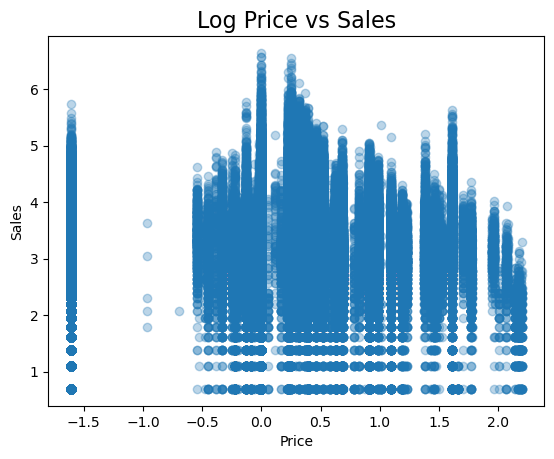

In [33]:

plt.scatter(train_processed["log_price"], train_processed["log_sales"], alpha=0.3)

plt.xlabel("Price")
plt.ylabel("Sales")
plt.title("Log Price vs Sales", size=16)
plt.savefig("visuals/logpricevssales.png")
plt.show()

In [34]:
train_processed = train_processed.dropna(subset=["lag1"])

In [35]:
test_processed = test_processed.dropna(subset=["lag1"])

In [36]:
# Base Model

formula = """log_sales ~ log_price
                       + snap
                       + C(item_id)
                       + C(store_id)
                       + C(wm_yr_wk)
                       + C(event_name_1_clean)
                       + year
                       + lag1"""

model_base_wm = smf.ols(formula, data=train_processed).fit(
    cov_type='cluster',
    cov_kwds={'groups': train_processed['item_id']}
)
print(model_base_wm.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                -1.372e+10
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               1.00
Time:                        12:51:59   Log-Likelihood:            -1.6021e+05
No. Observations:              197522   AIC:                         3.211e+05
Df Residuals:                  197202   BIC:                         3.243e+05
Df Model:                         319                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [37]:
# Base Model

formula_iso = """log_sales ~ log_price
                       + snap
                       + C(item_id)
                       + C(store_id)
                       + C(week52)
                       + C(event_name_1_clean)
                       + year
                       + lag1"""

model_base_isow = smf.ols(formula_iso, data=train_processed).fit(
    cov_type='cluster',
    cov_kwds={'groups': train_processed['item_id']}
)
print(model_base_isow.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     212.0
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.60e-49
Time:                        12:52:04   Log-Likelihood:            -1.6054e+05
No. Observations:              197522   AIC:                         3.214e+05
Df Residuals:                  197372   BIC:                         3.229e+05
Df Model:                         149                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [38]:
# Compare models formally
from statsmodels.stats.anova import anova_lm


print(f"Baseline Model with wm — AIC: {model_base_wm.aic:.1f}  Beta: {model_base_wm.params['log_price']:.4f}")
print(f"Baseline Model with isoweek — AIC: {model_base_isow.aic:.1f}  Beta: {model_base_isow.params['log_price']:.4f}")

Baseline Model with wm — AIC: 321067.6  Beta: -0.4150
Baseline Model with isoweek — AIC: 321378.2  Beta: -0.3819


- Elasticity conditional on purchase estimated because we dropped sales=0
+ elasticity is identified from:
- price differences
- within the same week
- across stores/items
- ==> The estimated price elasticity is −0.415, indicating that a 1% increase in price leads to approximately a 0.415% decrease in demand. This suggests demand is inelastic.


- Week fixed effects are used to isolate price elasticity by controlling for week-specific shocks. 
- However, they cannot be used for forecasting new weeks, 
- so RMSE is evaluated using time-generalizable features (month/seasonality/events) rather than week dummies.
- static regression model for a dynamic time series.
- Retail demand is highly autocorrelated.
- Without lag terms, prediction will be weak.

In [39]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


def relative_rmse(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse / np.mean(y_test)


def rmse(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse


def mae(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    return mae

# PREDICT ON TEST  
test_processed['log_sales_pred'] = model_base_isow.predict(test_processed)
test_processed['sales_pred']     = np.exp(test_processed['log_sales_pred'])

# 2. RMSE IN LOG SPACE (model's native space)  
rmse_log = np.sqrt(mean_squared_error(
    test_processed['log_sales'], test_processed['log_sales_pred']
))
print(f"RMSE (log space): {rmse_log:.4f}")

#  3. RMSE IN LEVELS (interpretable: units of sales)  
rmse_levels_sales = rmse(test_processed['sales'], test_processed['sales_pred'])

print(f"RMSE (levels):  {rmse_levels_sales:.4f}")

#relative RMSE
relative_rmse_sales=relative_rmse(test_processed['sales'], test_processed['sales_pred'])

print(f"relative RMSE sales: {relative_rmse_sales:.4f}")

#  4. MAPE (scale-free, useful across items) 
mape = np.mean(np.abs(
    (test_processed['sales'] - test_processed['sales_pred']) / test_processed['sales']
)) * 100
print(f"MAPE:             {mape:.2f}%")

#  5. R² on test set (out-of-sample)  
ss_res = np.sum((test_processed['log_sales'] - test_processed['log_sales_pred'])**2)
ss_tot = np.sum((test_processed['log_sales'] - test_processed['log_sales'].mean())**2)
r2_oos = 1 - ss_res / ss_tot
print(f"R² (out-of-sample): {r2_oos:.4f}")


mae_sales = mae(test_processed['sales'], test_processed['sales_pred'])
print(f"MAE:             {mae_sales:.3f}%")
#  6. PER-ITEM RMSE (spot weak items)  
item_rmse = test_processed.groupby('item_id').apply(
    lambda g: np.sqrt(mean_squared_error(g['log_sales'], g['log_sales_pred']))
).sort_values(ascending=False)
print("\nPer-item RMSE (log space):")
print(item_rmse)

RMSE (log space): 0.7676
RMSE (levels):  14.8936
relative RMSE sales: 0.5836
MAPE:             inf%
R² (out-of-sample): 0.6103
MAE:             9.456%

Per-item RMSE (log space):
item_id
FOODS_3_007    1.438366
FOODS_3_412    1.384936
FOODS_3_635    1.248641
FOODS_3_234    1.230295
FOODS_3_541    1.221416
FOODS_3_808    1.220688
FOODS_3_547    1.189979
FOODS_3_711    1.189070
FOODS_3_498    1.164305
FOODS_3_752    1.148152
FOODS_2_326    1.104209
FOODS_3_319    1.081853
FOODS_3_764    1.039494
FOODS_3_281    0.991868
FOODS_2_360    0.958691
FOODS_3_804    0.943488
FOODS_3_362    0.923856
FOODS_3_318    0.921650
FOODS_1_096    0.913378
FOODS_3_090    0.889775
FOODS_3_491    0.882068
FOODS_3_295    0.881304
FOODS_3_501    0.858753
FOODS_3_120    0.831112
FOODS_3_030    0.820656
FOODS_3_723    0.800741
FOODS_3_406    0.775326
FOODS_3_202    0.754836
FOODS_3_455    0.752838
FOODS_3_681    0.738001
FOODS_3_376    0.713743
FOODS_3_099    0.712153
FOODS_3_462    0.709545
FOODS_3_739    0.6800

In [40]:
print(f'avg sales: {round(test_processed["sales"].mean(),3)}')
print(f'std sales: {round(test_processed["sales"].std(), 3)}')
print("Relative RMSE:", round(rmse_levels_sales / test_processed["sales"].mean(), 3))

avg sales: 25.521
std sales: 23.262
Relative RMSE: 0.584


Metric	Value
RMSE (levels)	14.9 units
Average sales	25.5 units
Relative RMSE	0.58%
Out-of-sample R²	0.61

Interpretation:

Model explains 61% of demand variation out of sample.

Prediction error ≈ 58% of average demand.

For daily retail demand, this is quite reasonable.

Retail demand is noisy because of:

promotions

weather

store traffic

stockouts

local demand shocks
Your biggest gain came from:

lag1 coefficient ≈ 0.545

Meaning:

Yesterday’s demand explains ~55% of today's demand.

This is why:

R² jumped to 0.61

Retail demand is highly persistent.

Without lag variables, models perform much worse.

In [41]:
#daily revenue
test_predictions = test_processed[["date", "item_id","store_id","wm_yr_wk", "sales", "sales_pred", "sell_price"]]
    
test_predictions["rev_actual_daily"] = (
    test_predictions["sell_price"] * test_predictions["sales"]
)
test_predictions["rev_pred_daily"] = (
    test_predictions["sell_price"] * test_predictions["sales_pred"]
)

In [42]:
#rmse_levels_sales = rmse(test_processed['sales'], test_processed['sales_pred'])
#relative RMSE
#relative_rmse_sales=relative_rmse(test_processed['sales'], test_processed['sales_pred'])
rmse_rev_daily = rmse(test_predictions['rev_actual_daily'], test_predictions['rev_pred_daily'])
#relative RMSE
relative_rmse_rev_daily=relative_rmse(test_predictions['rev_actual_daily'], test_predictions['rev_pred_daily'])
mae_rev_daily = mae(test_predictions['rev_actual_daily'], test_predictions['rev_pred_daily'])

In [43]:
round(mae_rev_daily, 3)

16.405

In [44]:
#weekly aggregate predictions
weekly_pred = (
    test_processed
    .groupby(["item_id","store_id","wm_yr_wk"], as_index=False)
    .agg(
        sales_actual=("sales","sum"),
        sales_pred=("sales_pred","sum"),
        price=("sell_price","first")
    )
)

In [45]:
rmse_w = np.sqrt(
    mean_squared_error(
        weekly_pred["sales_actual"],
        weekly_pred["sales_pred"]
    )
)

print("Weekly RMSE:", rmse_w)

Weekly RMSE: 53.16308367243148


In [46]:
### print(f'avg sales: {round(weekly_pred["sales_actual"].mean(),3)}')
print(f'std sales: {round(weekly_pred["sales_actual"].std(), 3)}')
print("Relative RMSE:", round(rmse_w/ weekly_pred["sales_actual"].mean(), 3))
print(f"MAE Revenue Daily: {mae_rev_daily:.3f}")


std sales: 136.909
Relative RMSE: 0.302
MAE Revenue Daily: 16.405


In [47]:
## REVENUE maximisation weekly
weekly_pred["rev_actual"] = (
    weekly_pred["price"] * weekly_pred["sales_actual"]
)

weekly_pred["rev_pred"] = (
    weekly_pred["price"] * weekly_pred["sales_pred"]
)

In [48]:
rmse_sales_weekly_ols = rmse(weekly_pred['sales_actual'], weekly_pred['sales_pred'])
#relative RMSE
rel_rmse_sales_weekly_ols=relative_rmse(weekly_pred['sales_actual'], weekly_pred['sales_pred'])
#revenue
rmse_rev_weekly_ols= rmse(weekly_pred['rev_actual'], weekly_pred['rev_pred'])
#relative RMSE
rel_rmse_rev_weekly_ols=relative_rmse(weekly_pred['rev_actual'], weekly_pred['rev_pred'])
mae_rev_weekly= mae(weekly_pred['rev_actual'], weekly_pred['rev_pred'])

In [56]:
print(f'avg sales: {round(weekly_pred["sales_actual"].mean(),3)}')
print(f'std sales: {round(weekly_pred["sales_actual"].std(), 3)}')
print("Relative RMSE Sales:", round(rel_rmse_sales_weekly_ols, 3))
print("MAE Revenue weekly::", mae_rev_weekly)

avg sales: 175.911
std sales: 136.909
Relative RMSE Sales: 0.302
MAE Revenue weekly:: 64.15157239625853


In [57]:
#Daily Results
results = pd.DataFrame({
    "Model": [
        "OLS_daily", "OLS_daily", "OLS_daily", "OLS_daily",
        "OLS_weekly", "OLS_weekly", "OLS_weekly", "OLS_weekly"
        
    ],
    "Metric": [
        "RMSE Sales", "Relative RMSE Sales",
        "RMSE Revenue", "Relative RMSE Revenue",
        "RMSE Sales", "Relative RMSE Sales",
        "RMSE Revenue", "Relative RMSE Revenue"

    ],
    "Value": [
        rmse_levels_sales,
        relative_rmse_sales,
        rmse_rev_daily,
        relative_rmse_rev_daily,
        rmse_sales_weekly_ols, 
        rel_rmse_sales_weekly_ols, 
        rmse_rev_weekly_ols,
        rel_rmse_rev_weekly_ols        
    ]
})

print(results)

        Model                 Metric       Value
0   OLS_daily             RMSE Sales   14.893566
1   OLS_daily    Relative RMSE Sales    0.583587
2   OLS_daily           RMSE Revenue   32.618049
3   OLS_daily  Relative RMSE Revenue    0.687539
4  OLS_weekly             RMSE Sales   53.163084
5  OLS_weekly    Relative RMSE Sales    0.302216
6  OLS_weekly           RMSE Revenue  148.792290
7  OLS_weekly  Relative RMSE Revenue    0.455010


In [52]:
print(rel_rmse_rev_weekly_ols)

0.4550097946819771


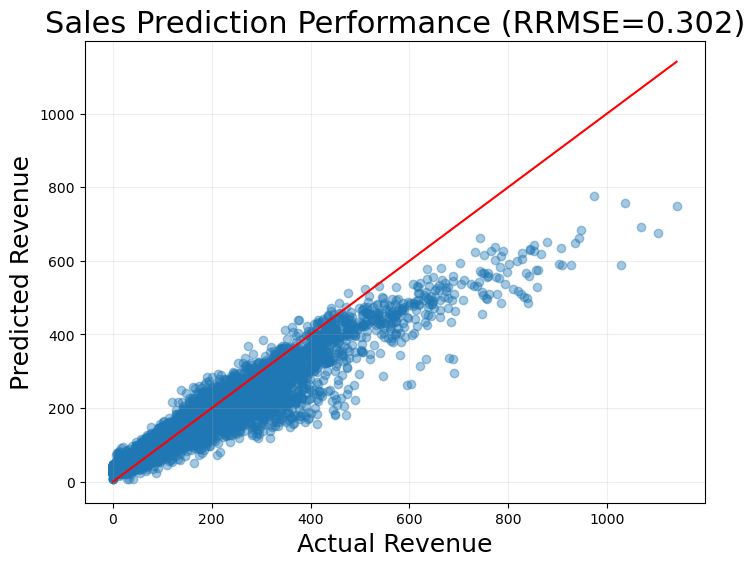

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    weekly_pred["sales_actual"],
    weekly_pred["sales_pred"],
    alpha=0.4
)

# perfect prediction line
min_val = weekly_pred["sales_actual"].min()
max_val = weekly_pred["sales_actual"].max()

plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.xlabel("Actual Revenue", size=18)
plt.ylabel("Predicted Revenue", size=18)

plt.title(f"Sales Prediction Performance (RRMSE={rel_rmse_sales_weekly_ols:.3f})", size=22)

plt.grid(alpha=0.2)
plt.savefig("visuals/Weekly_Sales_Prediction_vsActual.png")
plt.show()

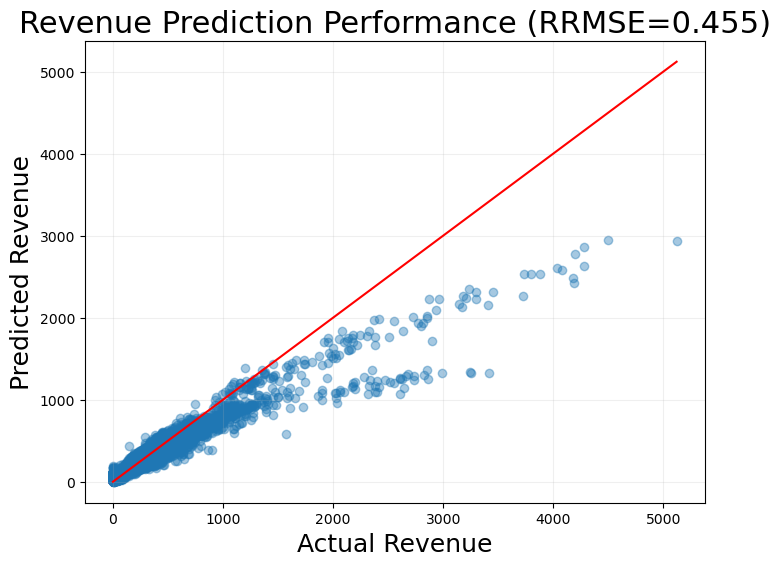

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    weekly_pred["rev_actual"],
    weekly_pred["rev_pred"],
    alpha=0.4
)

# perfect prediction line
min_val = weekly_pred["rev_actual"].min()
max_val = weekly_pred["rev_actual"].max()

plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.xlabel("Actual Revenue", size=18)
plt.ylabel("Predicted Revenue", size=18)

plt.title(f"Revenue Prediction Performance (RRMSE={rel_rmse_rev_weekly_ols:.3f})", size=22)

plt.grid(alpha=0.2)
plt.savefig("visuals/Weekly_Revenue_Prediction_vsActual.png")
plt.show()

- Predicted Revenue<Actual Revenue: the model systematically underpredicts high-revenue observations.
- OLS minimizes squared errors and therefore prefers to fit the center of the distribution, not the extremes.

In [ ]:
plt.figure(figsize=(5,5))

plt.scatter(
    weekly_pred["rev_actual"],
    weekly_pred["rev_pred"],
    alpha=0.25
)

min_val = weekly_pred["rev_actual"].min()
max_val = weekly_pred["rev_actual"].max()

plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Revenue Prediction (Log Scale)")

plt.grid(alpha=0.2)
plt.savefig("visuals/LOG_Weekly_Revenue_Prediction_vsActual.png")
plt.show()

- The model underpredicts high revenue spikes.

In [54]:
#Saving the base model
import joblib

joblib.dump(model_base_isow, "models/base_ols_model.joblib")

['models/base_ols_model.joblib']

In [55]:
sku = "FOODS_1_096"
store = "WI_2"

sample = train_processed[
    (train_processed["item_id"] == sku) &
    (train_processed["store_id"] == store)
].iloc[0].copy()

In [56]:
import numpy as np
import pandas as pd

price_grid = np.linspace(
    sample["sell_price"] * 0.5,
    sample["sell_price"] * 1.5,
    50
)

sim_data = pd.DataFrame([sample] * len(price_grid))
sim_data["sell_price"] = price_grid
sim_data["log_price"] = np.log(price_grid)

In [57]:
sim_data["log_sales_pred"] = model_base_isow.predict(sim_data)
sim_data["sales_pred"] = np.exp(sim_data["log_sales_pred"]) - 1

In [58]:
sim_data["revenue_pred"] = sim_data["sales_pred"] * sim_data["sell_price"]

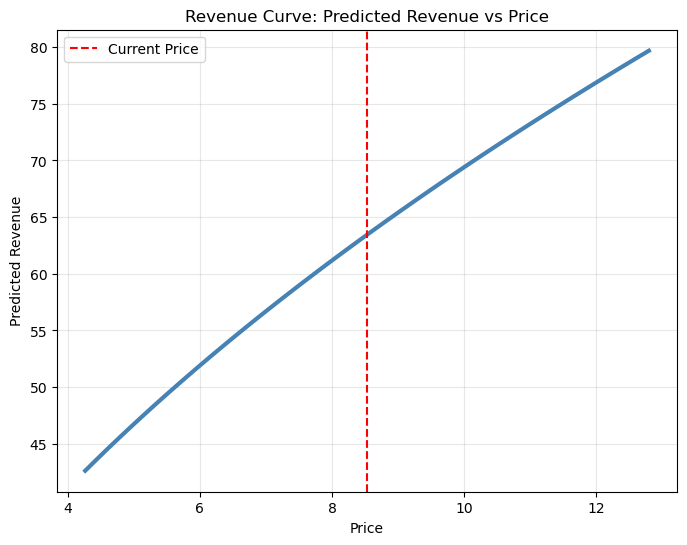

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    sim_data["sell_price"],
    sim_data["revenue_pred"],
    color="steelblue",
    lw=3
)

plt.axvline(sample["sell_price"], color="red", linestyle="--", label="Current Price")

plt.title("Revenue Curve: Predicted Revenue vs Price")
plt.xlabel("Price")
plt.ylabel("Predicted Revenue")

plt.legend()
plt.grid(alpha=0.3)
plt.savefig("visuals/simulation_withpr_elasticities.png")
plt.show()

In [60]:
#weekly
import re
weekly= (
    df.sort_values(["item_id", "store_id", "wm_yr_wk", "date"])
    .groupby(["item_id", "store_id", "wm_yr_wk"], as_index=False)
    .agg(
        week_start=("date", "min"),
        sales=("sales", "sum"),
        sell_price=("sell_price", "first"),
        state_id=("state_id", "first"),
        snap_CA=("snap_CA", "max"),
        snap_TX=("snap_TX", "max"),
        snap_WI=("snap_WI", "max"),
        event_name_1_clean=("event_name_1_clean", "first"),
    )
)

In [61]:
split_date = weekly["week_start"].quantile(0.8)

train_w = weekly[weekly["week_start"] <= split_date].copy()
test_w  = weekly[weekly["week_start"] > split_date].copy()

In [62]:
train_w.shape, test_w.shape

((32494, 11), (8100, 11))

In [63]:
train_processed_w = fb_w.fit_transform(train_w)
test_processed_w  = fb_w.transform(test_w)

In [64]:
train_processed_w= train_processed_w[train_processed_w['sales'] > 0].copy()

In [65]:
(train_processed_w['sales']== 0).sum()

0

In [66]:
# Base Model weekly

formula_w = """log_sales ~ log_price
                       + snap
                       + C(item_id)
                       + C(store_id)
                       + C(event_name_1_clean)
                       + C(month)
                       + year"""

model_base_weekly = smf.ols(formula_w, data=train_processed_w).fit(
    cov_type='cluster',
    cov_kwds={'groups': train_processed_w['item_id']}
)
print(model_base_weekly.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     299.1
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           7.07e-51
Time:                        10:38:11   Log-Likelihood:                -32091.
No. Observations:               30185   AIC:                         6.435e+04
Df Residuals:                   30100   BIC:                         6.506e+04
Df Model:                          84                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [67]:
from sklearn.metrics import mean_squared_error

# ── MODEL 1: OLS POOLED (baseline) ──────────────────────────────────
test['pred_pooled'] = np.exp(model.predict(test))

# ── MODEL 2: OLS PER-ITEM ────────────────────────────────────────────
test['pred_het'] = np.exp(model_het.predict(test))

# ── EVALUATE ─────────────────────────────────────────────────────────
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs(y_true - y_pred) / y_true).mean() * 100
    r2   = 1 - ((y_true - y_pred)**2).sum() / ((y_true - y_true.mean())**2).sum()
    print(f"{name:<35} RMSE: {rmse:7.3f}  MAPE: {mape:6.2f}%  R²: {r2:.3f}")

print("=" * 70)
print(f"{'MODEL':<35} {'RMSE':>7}  {'MAPE':>8}  {'R²':>6}")
print("=" * 70)
evaluate(test['sales'], test['pred_pooled'], 'OLS Pooled β=-0.92 (baseline)')
evaluate(test['sales'], test['pred_het'],    'OLS Per-item β')
print("=" * 70)

NameError: name 'model' is not defined

In [ ]:
print(train['is_promo'].value_counts())
print(train.groupby('is_promo')['sales'].mean())
# If promo weeks don't show higher mean sales → threshold is wrong

In [ ]:
# Check correlation between log_price and is_promo
print(train[['log_price','is_promo']].corr())
# Expected: negative correlation ~ -0.3 to -0.6 → confirms collinearity

Promo weeks do show higher sales (44.6 vs 32.4) — so the direction is right economically. The issue is purely statistical: 6,722 promo observations vs 190,950 non-promo — that's only 3.4% of your data flagged as promo. With clustered SEs at the item level, this thin signal isn't enough to get a significant coefficient. corr is low. collinearity is not the issue.

In [ ]:
# How many promo weeks per item?
print(train.groupby('item_id')['is_promo'].sum().sort_values())
# Many zeros → those items never trigger the flag

# What does a promo week actually look like?
print(train[train['is_promo']==1][['item_id','wm_yr_wk','sell_price','modal_price','sales']].head(20))
# Are these genuine short-term dips or permanent price changes?
#we are dropping promo for now.

In [ ]:
print(f'avg sales: {round(weekly_sku["sales"].mean(),3)}')
print(f'std sales: {round(weekly_sku["sales"].std(), 3)}')
print("Relative RMSE:", round(rmse_units / weekly_sku["sales"].mean(), 3))

Base forecast model is barely better than predicting a constant mean!

Modeling Strategy Roadmap

Step 1:
Single SKU, pooled across stores

Step 2:
Estimate elasticity

Step 3:
Check sign and magnitude

Step 4:
Evaluate RMSE

Step 5:
Then move to ML improvement